# Heart Failure Prediction

## Importing Libraries

In [1]:
import pandas as pd #for working with tabular datasets
import numpy as np #for numerical operations
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler #for cross vaildation testing model stability across folds 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, KFold

## Loading the dataset 

In [2]:
df = pd.read_csv("heart.csv")
#checking the features and some values
#quick look 
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (918, 12)

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Data exploration 

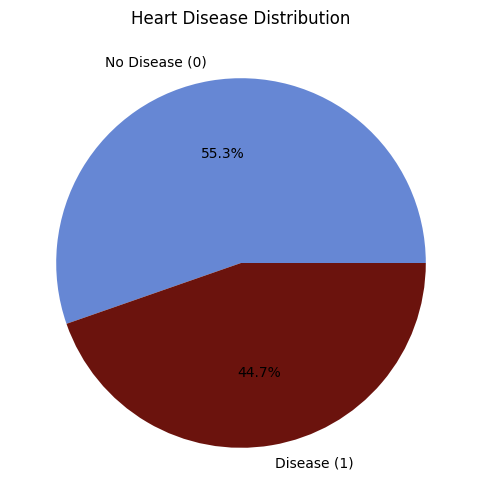

In [3]:
# Heart Disease Class Distribution Graph
plt.figure(figsize=(6,6)) 
df['HeartDisease'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    labels=['No Disease (0)', 'Disease (1)'],
    colors=['#6687d4', '#6b130d']) 
plt.title('Heart Disease Distribution')
plt.ylabel('')
plt.show()


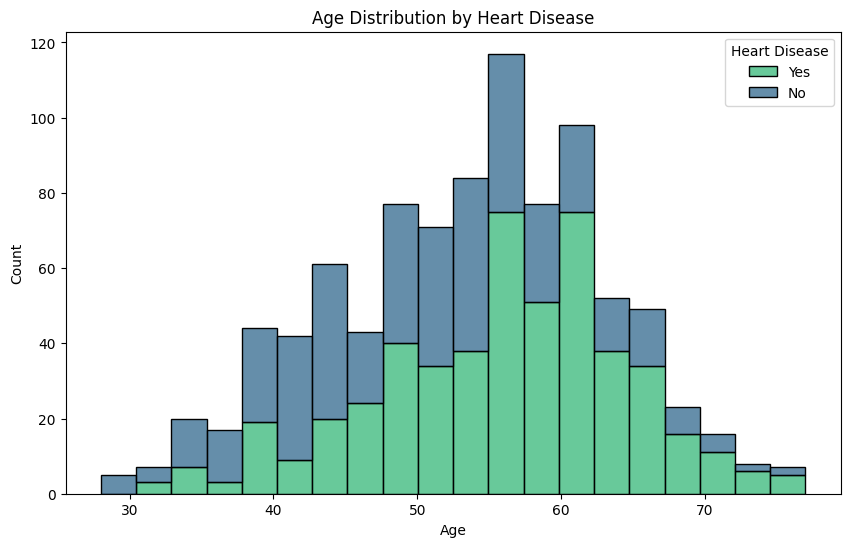

In [4]:
# GAge Distribution by Heart Diseas
plt.figure(figsize=(10,6))  
sns.histplot(
    data=df,                 
    x='Age',                 
    hue='HeartDisease',      
    multiple='stack',        
    bins=20,                 
    palette='viridis'        
)
plt.title('Age Distribution by Heart Disease') 
plt.xlabel('Age')           
plt.ylabel('Count')         
plt.legend(title='Heart Disease', labels=['Yes', 'No'])

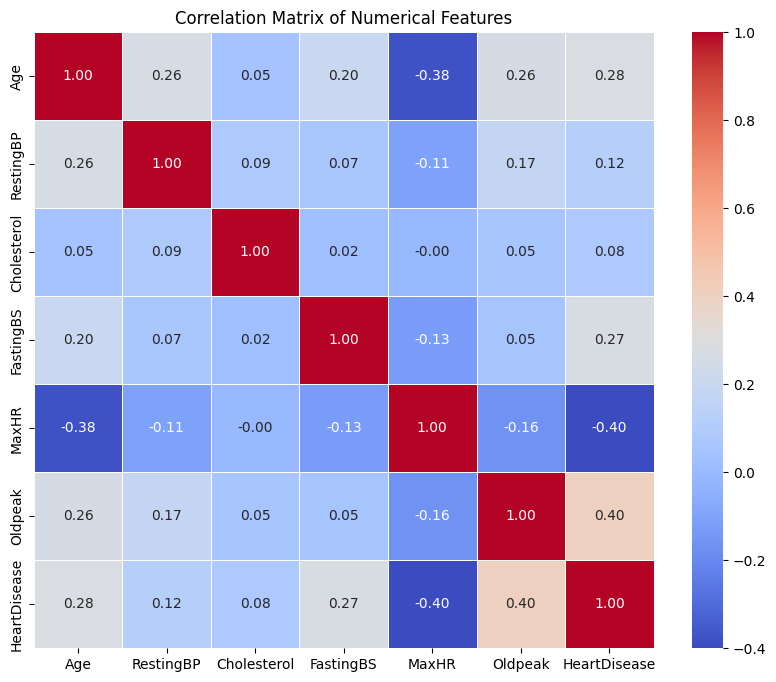

In [16]:
# Correlation matrix 

numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
corr = df[numerical_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Data Cleaning

In [6]:
#cheking for missing value 
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['HeartDisease'].value_counts(normalize=True))


Shape: (918, 12)

Missing values:
 Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Target distribution:
 HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


In [7]:
# Cleaning replaced invalid 0s in RestingBP and Cholesterol with the median 
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)

df['RestingBP'] = df['RestingBP'].fillna(df['RestingBP'].median())
df['Cholesterol'] = df['Cholesterol'].fillna(df['Cholesterol'].median())

In [8]:
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})
df['ExerciseAngina'] = df['ExerciseAngina'].map({'Y': 1, 'N': 0})

# One-hot encoding for multi-class categoricals
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True, dtype=int)
df

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140.0,289.0,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160.0,180.0,0,156,0,1.0,1,0,1,0,1,0,1,0
2,37,1,130.0,283.0,0,98,0,0.0,0,1,0,0,0,1,0,1
3,48,0,138.0,214.0,0,108,1,1.5,1,0,0,0,1,0,1,0
4,54,1,150.0,195.0,0,122,0,0.0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110.0,264.0,0,132,0,1.2,1,0,0,1,1,0,1,0
914,68,1,144.0,193.0,1,141,0,3.4,1,0,0,0,1,0,1,0
915,57,1,130.0,131.0,0,115,1,1.2,1,0,0,0,1,0,1,0
916,57,0,130.0,236.0,0,174,0,0.0,1,1,0,0,0,0,1,0


## Data Splitting & Feature Scaling

In [9]:
# Features and target
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# Spliting the data into test and train 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [10]:
# Standardization
#Numerical features were standardized using StandardScaler
scaler = StandardScaler()
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])
# used centralition 

## Model Training and evaluation 

In [11]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision (HeartDisease=1): {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall (HeartDisease=1): {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score (HeartDisease=1): {f1_score(y_test, y_pred_lr):.4f}")



Logistic Regression
Accuracy: 0.8750
Precision (HeartDisease=1): 0.8990
Recall (HeartDisease=1): 0.8725
F1-Score (HeartDisease=1): 0.8856


In [12]:
# Decision Tree 
dt = DecisionTreeClassifier(
    max_depth=None,          
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)


dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree (Single Train-Test Split)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision (HeartDisease=1): {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall (HeartDisease=1): {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1-Score (HeartDisease=1): {f1_score(y_test, y_pred_dt):.4f}")


Decision Tree (Single Train-Test Split)
Accuracy: 0.7554
Precision (HeartDisease=1): 0.7767
Recall (HeartDisease=1): 0.7843
F1-Score (HeartDisease=1): 0.7805


In [13]:
# K-Fold
print("K-Fold")
kfold_normal = KFold(n_splits=10, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(dt, X, y, cv=kfold_normal, scoring='accuracy')
cv_precision = cross_val_score(dt, X, y, cv=kfold_normal, scoring='precision')
cv_recall = cross_val_score(dt, X, y, cv=kfold_normal, scoring='recall')
cv_f1 = cross_val_score(dt, X, y, cv=kfold_normal, scoring='f1')

print(f"Accuracy:  {cv_accuracy.mean():.4f}")
print(f"Precision: {cv_precision.mean():.4f}")
print(f"Recall:    {cv_recall.mean():.4f}")
print(f"F1-Score:  {cv_f1.mean():.4f}")


K-Fold
Accuracy:  0.7854
Precision: 0.7974
Recall:    0.8216
F1-Score:  0.8083


In [14]:
# Random Forest we don't scaling but we're using it for consistency
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision (HeartDisease=1): {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall (HeartDisease=1): {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score (HeartDisease=1): {f1_score(y_test, y_pred_rf):.4f}")

Random Forest
Accuracy: 0.8750
Precision (HeartDisease=1): 0.8911
Recall (HeartDisease=1): 0.8824
F1-Score (HeartDisease=1): 0.8867


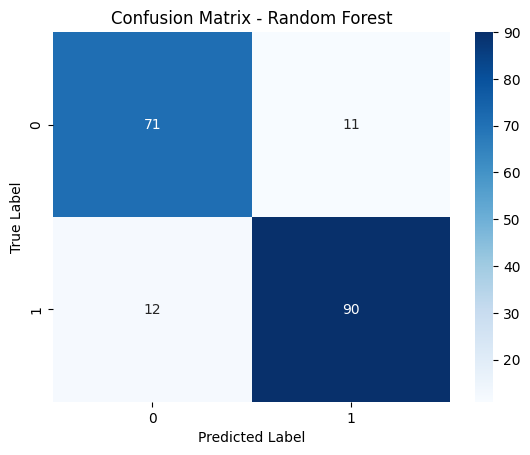

False Negatives (missed heart disease cases): 12


In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Optional: explicitly show false negatives (important in healthcare)
tn, fp, fn, tp = cm.ravel()
print("False Negatives (missed heart disease cases):", fn)